# GAN usage in DEGANN

#### This notebook demonstrates how to create and train a GAN using DEGANN.

**Import necessary libraries:**

In [1]:
import sys
sys.path.append("C:\\Users\\serge\\Desktop\\degann\\degann")

In [2]:
import tensorflow as tf
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from degann.networks.topology.GAN.parameter_space import GANParameterSpace
from degann.search_algorithms.grid_search import grid_search
from degann.search_algorithms.random_search import random_search
from degann.search_algorithms.simulated_annealing import simulated_annealing
from degann.networks.topology.GAN.tf_gan import TensorflowGAN

**Prepare data for training:**

In [3]:
def lf_ode1(t, y):
    return -3 * y

sol = solve_ivp(lf_ode1, [0, 5], [1], t_eval=np.linspace(0, 5, 1000))
X, y = sol.t.reshape(-1, 1), sol.y[0].reshape(-1, 1)

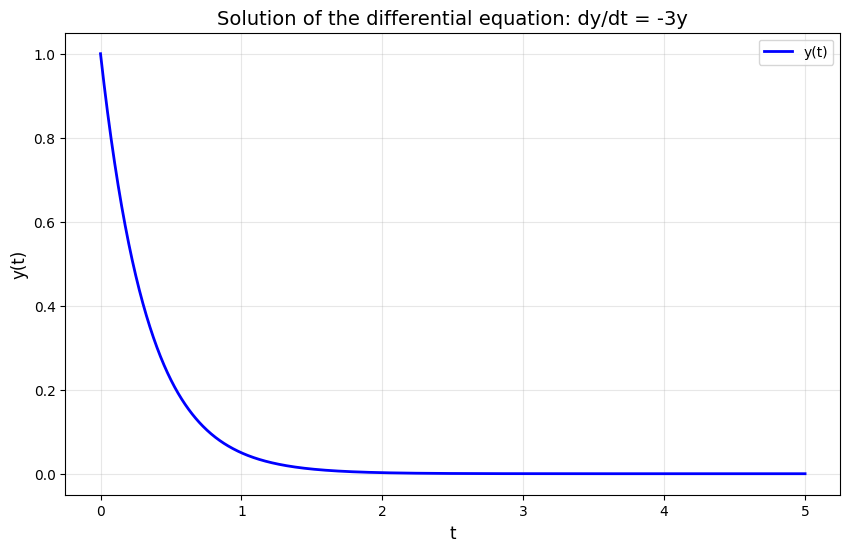

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'b-', linewidth=2, label='y(t)')
plt.xlabel('t', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.title('Solution of the differential equation: dy/dt = -3y', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [5]:
sol = solve_ivp(lf_ode1, [0, 5], [1], t_eval=np.linspace(0, 5, 500))
X_new, y_new = sol.t.reshape(-1, 1), sol.y[0].reshape(-1, 1)

In [6]:
def plot_diff_grid(t_new, y_new, y_pred):
    plt.figure(figsize=(12, 6))
    plt.plot(t_new, y_new, 'b-', linewidth=2, label='True solution', alpha=0.7)
    plt.plot(t_new, y_pred, 'r--', linewidth=2, label='NN predictions', alpha=0.7)
    plt.xlabel('t', fontsize=12)
    plt.ylabel('y(t)', fontsize=12)
    plt.title('Model Generalization on Different Grid', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

**Define and create paramter object for GAN:**

In [7]:
GAN_params = GANParameterSpace(
    gen_input_size=1,
    gen_output_size=1,
    gen_layer_sizes=[8, 16, 24, 32],
    gen_min_depth=2,
    gen_max_depth=4,
    gen_activation_funcs=["relu", "tanh", "swish"],
    gen_out_activation="linear",

    disc_layer_sizes=[8, 16, 24, 32],
    disc_min_depth=2,
    disc_max_depth=4,
    disc_activation_funcs=["relu", "tanh"],

    gen_optimizers=["Adam", "RMSprop"],
    disc_optimizers=["Adam", "RMSprop"],
    gen_loss_funcs=["MeanSquaredError"],
    disc_loss_funcs=["MeanSquaredError"],
    epochs=[50, 100, 150],
)

In [8]:
GAN_params_light = GANParameterSpace(
    gen_input_size=1,
    gen_output_size=1,
    gen_layer_sizes=[8, 16],         
    gen_min_depth=3,
    gen_max_depth=3,                  
    gen_activation_funcs=["relu"],   
    gen_out_activation="linear",

    disc_layer_sizes=[8, 16],       
    disc_min_depth=3,
    disc_max_depth=3,            
    disc_activation_funcs=["tanh"],

    gen_optimizers=["Adam"],
    disc_optimizers=["Adam"],
    gen_loss_funcs=["MeanSquaredError"],
    disc_loss_funcs=["MeanSquaredError"],
    epochs=[15],           
)

**Grid search**

In [9]:
grid_loss, grid_epoch, grid_loss_name, grid_optimizer, grid_nn = grid_search(
    data=(X, y),
    params=GAN_params_light,
    verbose=True,
)

1 2026-05-10 22:37:06
2 2026-05-10 22:37:11
3 2026-05-10 22:37:17
4 2026-05-10 22:37:22
5 2026-05-10 22:37:29
6 2026-05-10 22:37:34
7 2026-05-10 22:37:40
8 2026-05-10 22:37:46
9 2026-05-10 22:37:52
10 2026-05-10 22:37:58
11 2026-05-10 22:38:04
12 2026-05-10 22:38:10
13 2026-05-10 22:38:15
14 2026-05-10 22:38:22
15 2026-05-10 22:38:27
16 2026-05-10 22:38:33
17 2026-05-10 22:38:38
18 2026-05-10 22:38:44
19 2026-05-10 22:38:49
20 2026-05-10 22:38:54
21 2026-05-10 22:39:00
22 2026-05-10 22:39:05
23 2026-05-10 22:39:10
24 2026-05-10 22:39:16
25 2026-05-10 22:39:21
26 2026-05-10 22:39:26
27 2026-05-10 22:39:31
28 2026-05-10 22:39:37
29 2026-05-10 22:39:42
30 2026-05-10 22:39:47
31 2026-05-10 22:39:52
32 2026-05-10 22:39:57
33 2026-05-10 22:40:03
34 2026-05-10 22:40:08
35 2026-05-10 22:40:13
36 2026-05-10 22:40:18
37 2026-05-10 22:40:24
38 2026-05-10 22:40:29
39 2026-05-10 22:40:35
40 2026-05-10 22:40:40
41 2026-05-10 22:40:45
42 2026-05-10 22:40:51
43 2026-05-10 22:40:56
44 2026-05-10 22:41:

In [10]:
print(f"Loss: {grid_loss}")
print(f"Generator Layers: {grid_nn['config']['gen_config']['layer_sizes']}")
print(f"Discriminator Layers: {grid_nn['config']['disc_config']['layer_sizes']}")
print(f"Generator Activations: {grid_nn['config']['gen_config']['activation_funcs'][:-1]}")
print(f"Discriminator Activations: {grid_nn['config']['disc_config']['activation_funcs'][:-1]}")
print(f"Optimizer: {grid_optimizer}")
print(f"Loss function: {grid_loss_name}")

Loss: 0.24181585013866425
Generator Layers: [8, 8, 16]
Discriminator Layers: [16, 8, 8]
Generator Activations: ['relu', 'relu', 'relu']
Discriminator Activations: ['tanh', 'tanh', 'tanh']
Optimizer: ('Adam', 'Adam')
Loss function: ('MeanSquaredError', 'MeanSquaredError')


In [11]:
nn = TensorflowGAN.from_dict(grid_nn)
y_pred = nn(X_new)

C:\Users\serge\Desktop\degann\venv\lib\site-packages\keras\src\layers\layer.py:361: UserWarning: `build()` was called on layer '', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


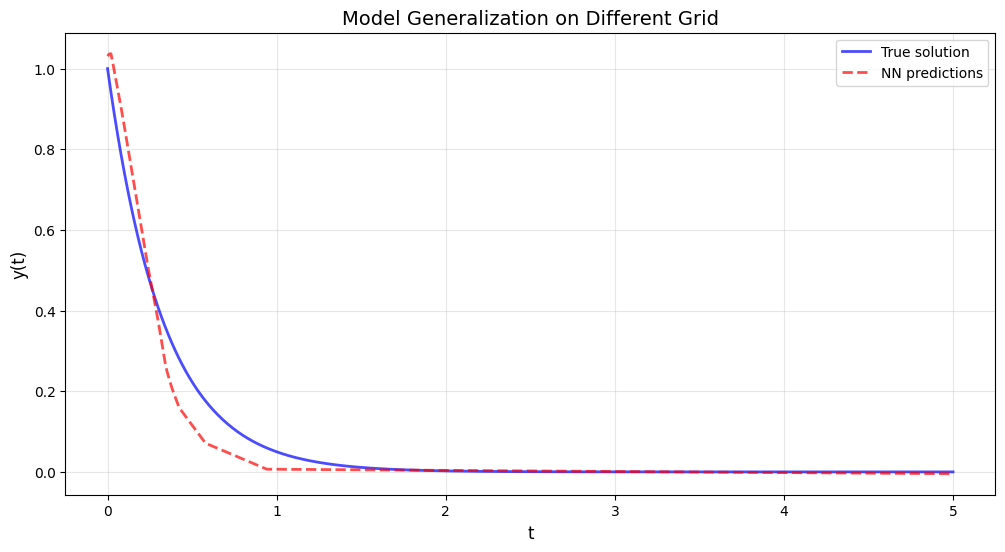

In [12]:
plot_diff_grid(X_new, y_new, y_pred)

**Random search**

In [21]:
random_loss, random_epoch, random_loss_name, random_optimizer, random_nn = random_search(
    data=(X, y),
    params=GAN_params,
    iterations=10,
    verbose=True
)

1/10 2026-05-10 22:49:56
2/10 2026-05-10 22:50:11
3/10 2026-05-10 22:50:20
4/10 2026-05-10 22:50:39
5/10 2026-05-10 22:50:48
6/10 2026-05-10 22:51:07
7/10 2026-05-10 22:51:19
8/10 2026-05-10 22:51:32
9/10 2026-05-10 22:51:52
10/10 2026-05-10 22:52:10


In [22]:
print(f"Loss: {random_loss}")
print(f"Generator Layers: {random_nn['config']['gen_config']['layer_sizes']}")
print(f"Discriminator Layers: {random_nn['config']['disc_config']['layer_sizes']}")
print(f"Generator Activations: {random_nn['config']['gen_config']['activation_funcs'][:-1]}")
print(f"Discriminator Activations: {random_nn['config']['disc_config']['activation_funcs'][:-1]}")
print(f"Optimizer: {random_optimizer}")
print(f"Loss function: {random_loss_name}")

Loss: 0.24753999710083008
Generator Layers: [8, 24, 8]
Discriminator Layers: [32, 24, 32]
Generator Activations: ['tanh', 'tanh', 'relu']
Discriminator Activations: ['relu', 'tanh', 'relu']
Optimizer: ('RMSprop', 'RMSprop')
Loss function: ('MeanSquaredError', 'MeanSquaredError')


In [23]:
nn = TensorflowGAN.from_dict(random_nn)
y_pred = nn(X_new)

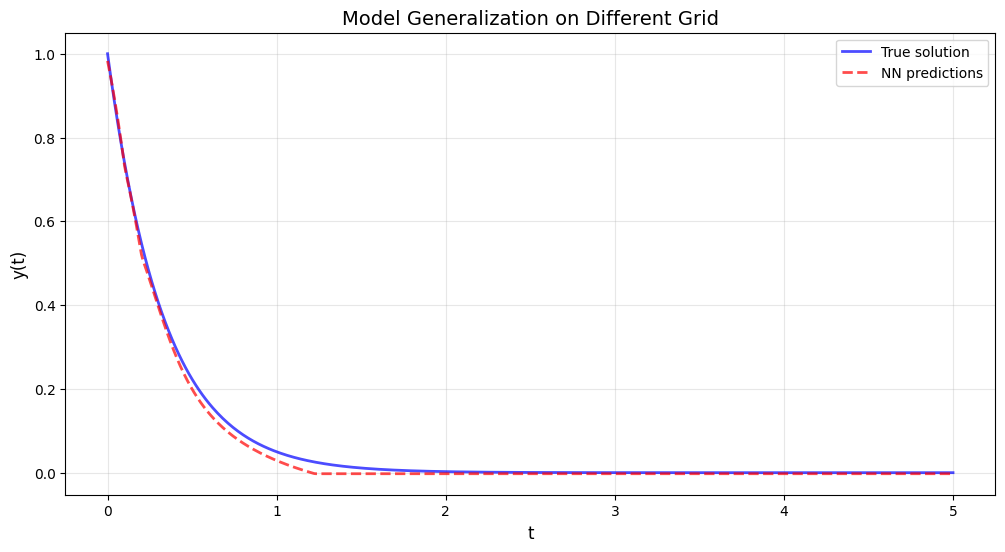

In [24]:
plot_diff_grid(X_new, y_new, y_pred)

**Simulated annealing algorithm**

In [17]:
sim_loss, sim_epoch, sim_loss_name, sim_optimizer, sim_nn, sim_iteration = simulated_annealing(
    data=(X, y),
    params=GAN_params,
    max_iter=10,
    threshold=0.25,
    verbose=True
)

In [18]:
print(f"Loss: {sim_loss}")
print(f"Generator Layers: {sim_nn['config']['gen_config']['layer_sizes']}")
print(f"Discriminator Layers: {sim_nn['config']['disc_config']['layer_sizes']}")
print(f"Generator Activations: {sim_nn['config']['gen_config']['activation_funcs'][:-1]}")
print(f"Discriminator Activations: {sim_nn['config']['disc_config']['activation_funcs'][:-1]}")
print(f"Optimizer: {sim_optimizer}")
print(f"Loss function: {sim_loss_name}")

Loss: 0.2494538128376007
Generator Layers: [8, 24, 16]
Discriminator Layers: [8, 8, 16, 32]
Generator Activations: ['relu', 'swish', 'swish']
Discriminator Activations: ['tanh', 'tanh', 'relu', 'tanh']
Optimizer: ('Adam', 'Adam')
Loss function: ('MeanSquaredError', 'MeanSquaredError')


In [19]:
nn = TensorflowGAN.from_dict(sim_nn)
y_pred = nn(X_new)

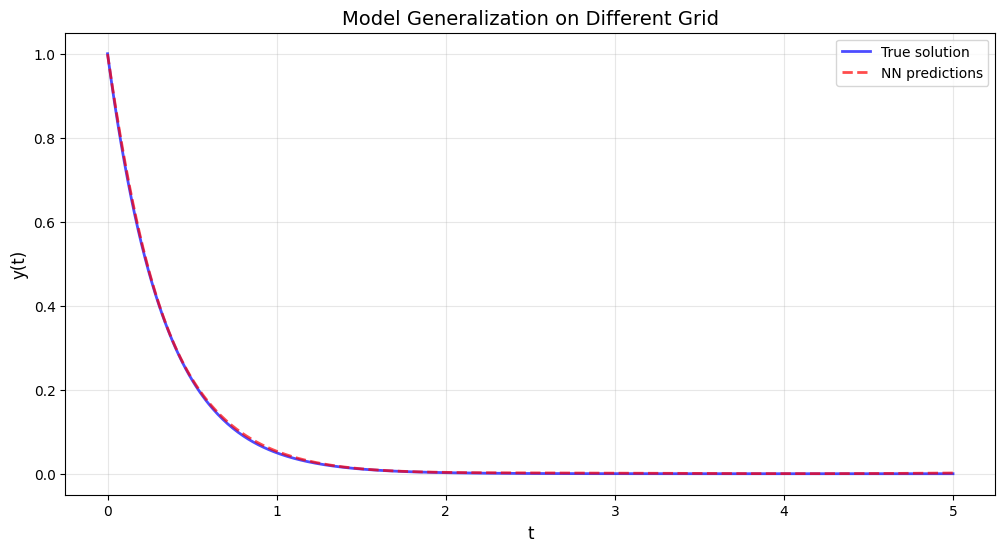

In [20]:
plot_diff_grid(X_new, y_new, y_pred)